In [ ]:
# CELL 1 — Install (run once)
!pip install torch torchvision timm matplotlib seaborn scikit-learn tqdm pillow

In [ ]:
# CELL 2 — Imports & Config
import os, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision import models
import timm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc as sk_auc

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

CONFIG = {
    'img_size'      : 224,
    'num_classes'   : 4,
    'batch_size'    : 16,
    'num_workers'   : 0,
    'lr_warmup'     : 1e-4,
    'lr_full'       : 1e-4,
    'lr_calib'      : 1e-3,
    'weight_decay'  : 1e-5,
    'epochs_warmup' : 15,
    'epochs_full'   : 50,
    'epochs_calib'  : 15,
    'lambda1'       : 0.3,
    'cnn_embed_dim' : 256,
    'num_heads_ca'  : 8,
    'dropout'       : 0.3,
    'class_names'   : ['Glioma', 'Meningioma', 'Pituitary', 'Normal'],
    'data_dir'      : r'/content/drive/MyDrive/dataset',
    'checkpoint_dir': './checkpoints',
}
CLASS_NAMES = CONFIG['class_names']
os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
print('Config ready ✓')

Device : cuda
GPU    : Tesla T4
Config ready ✓


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELL 3 — Verify Dataset
DATA_DIR = Path(CONFIG['data_dir'])
for split in ['Training', 'Testing']:
    p = DATA_DIR / split
    if p.exists():
        print(f'\n✅ {split}:')
        for d in sorted(p.iterdir()):
            if d.is_dir():
                print(f'   {d.name:15s}: {len(list(d.glob("*.[jp][pn]g")))} images')
    else:
        print(f'❌ NOT FOUND: {p}')


✅ Training:
   glioma         : 1400 images
   meningioma     : 1400 images
   notumor        : 1400 images
   pituitary      : 1400 images

✅ Testing:
   glioma         : 400 images
   meningioma     : 400 images
   notumor        : 400 images
   pituitary      : 400 images


In [ ]:
# CELL 4 — Dataset & DataLoaders
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
S    = CONFIG['img_size']

train_tf = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_tf = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

LABEL_MAP = {'glioma':0, 'meningioma':1, 'pituitary':2, 'notumor':3}

class BrainTumorDataset(Dataset):
    def __init__(self, root_dirs, transform=None):
        self.transform = transform
        self.samples   = []
        for root in root_dirs:
            for d in sorted(root.iterdir()):
                if not d.is_dir(): continue
                lbl = LABEL_MAP.get(d.name.lower())
                if lbl is None: continue
                for p in d.glob('*.[jp][pn]g'):
                    self.samples.append((p, lbl))
    def __len__(self):  return len(self.samples)
    def __getitem__(self, i):
        p, lbl = self.samples[i]
        img = Image.open(p).convert('RGB')
        return (self.transform(img) if self.transform else img), lbl
    def get_labels(self): return [s[1] for s in self.samples]

class SubsetTf(Dataset):
    def __init__(self, ds, idx, tf):
        self.ds, self.idx, self.tf = ds, idx, tf
    def __len__(self):  return len(self.idx)
    def __getitem__(self, i):
        p, lbl = self.ds.samples[self.idx[i]]
        return self.tf(Image.open(p).convert('RGB')), lbl

full_ds    = BrainTumorDataset([DATA_DIR/'Training'])
all_labels = full_ds.get_labels()
tr_idx, va_idx = train_test_split(range(len(full_ds)), test_size=0.2,
                                   stratify=all_labels, random_state=SEED)
train_ds = SubsetTf(full_ds, tr_idx, train_tf)
val_ds   = SubsetTf(full_ds, va_idx, val_tf)
test_ds  = BrainTumorDataset([DATA_DIR/'Testing'], transform=val_tf)

train_labels  = [all_labels[i] for i in tr_idx]
class_counts  = np.bincount(train_labels, minlength=4)
class_weights = 1.0 / class_counts
sampler = WeightedRandomSampler([class_weights[l] for l in train_labels],
                                  len(train_labels), replacement=True)

BS, NW = CONFIG['batch_size'], CONFIG['num_workers']
train_loader = DataLoader(train_ds, batch_size=BS, sampler=sampler, num_workers=NW)
val_loader   = DataLoader(val_ds,   batch_size=BS, shuffle=False,  num_workers=NW)
test_loader  = DataLoader(test_ds,  batch_size=BS, shuffle=False,  num_workers=NW)

print(f'Train:{len(train_ds):5d}  Val:{len(val_ds):5d}  Test:{len(test_ds):5d}')

Train: 4480  Val: 1120  Test: 1600


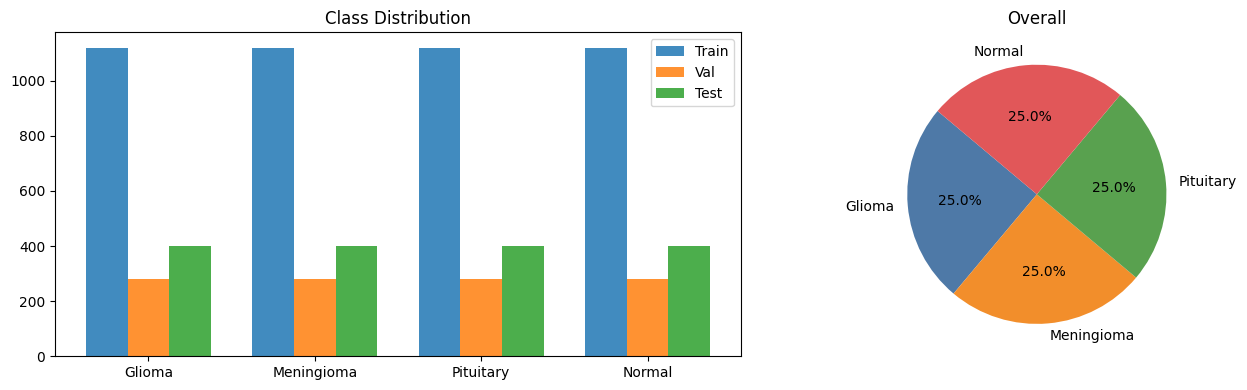

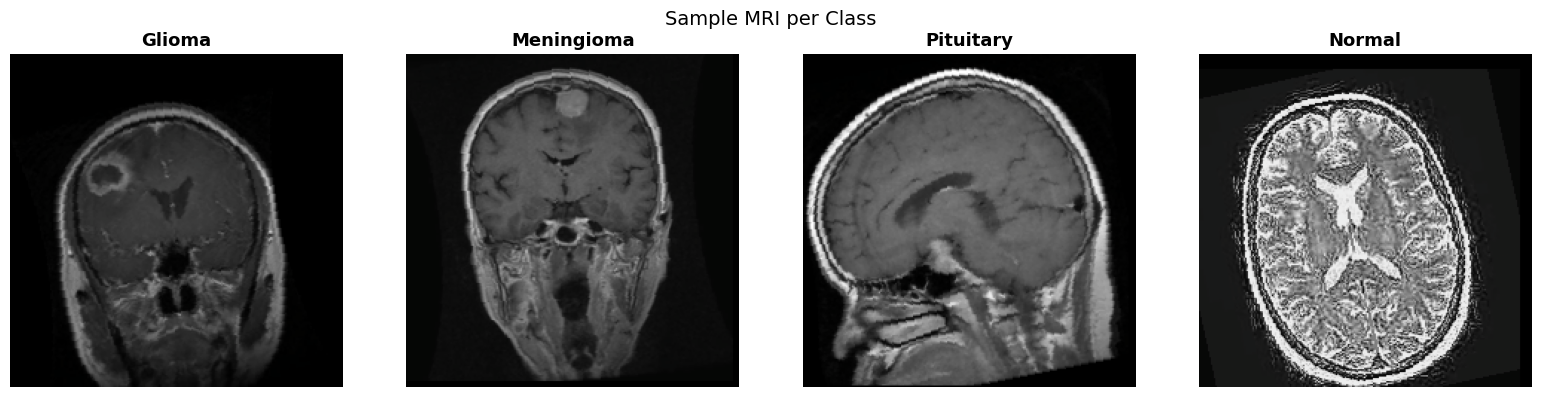

In [ ]:
# CELL 5 — Visualise Dataset
colors = ['#4e79a7','#f28e2b','#59a14f','#e15759']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x, w = np.arange(4), 0.25
for k,(nm,labs) in enumerate({'Train':train_labels,
                               'Val':[all_labels[i] for i in va_idx],
                               'Test':test_ds.get_labels()}.items()):
    axes[0].bar(x+k*w, np.bincount(labs,minlength=4), w, label=nm, alpha=0.85)
axes[0].set_xticks(x+w); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_title('Class Distribution'); axes[0].legend()
axes[1].pie(np.bincount(all_labels,minlength=4), labels=CLASS_NAMES,
            colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Overall')
plt.tight_layout(); plt.show()

unnorm = transforms.Normalize([-m/s for m,s in zip(MEAN,STD)],[1/s for s in STD])
fig, axes = plt.subplots(1,4,figsize=(16,4))
shown = {i:False for i in range(4)}
for img,lbl in train_ds:
    if not shown[lbl]:
        shown[lbl]=True
        axes[lbl].imshow(unnorm(img).permute(1,2,0).clamp(0,1).numpy())
        axes[lbl].set_title(CLASS_NAMES[lbl],fontsize=13,fontweight='bold')
        axes[lbl].axis('off')
    if all(shown.values()): break
plt.suptitle('Sample MRI per Class',fontsize=14); plt.tight_layout(); plt.show()

In [ ]:
# CELL 6 — Multi-Scale CNN Extractor
class MultiScaleCNNExtractor(nn.Module):
    def __init__(self, embed_dim=256, pretrained=True):
        super().__init__()
        bb = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None)
        self.stem   = nn.Sequential(bb.conv1,bb.bn1,bb.relu,bb.maxpool)
        self.layer1 = bb.layer1
        self.layer2 = bb.layer2
        self.layer3 = bb.layer3
        mk = lambda ci: nn.Sequential(nn.Conv2d(ci,embed_dim,1),nn.BatchNorm2d(embed_dim),nn.ReLU())
        self.proj_low  = mk(256)
        self.proj_mid  = mk(512)
        self.proj_high = mk(1024)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.sw  = nn.Parameter(torch.ones(3)/3)

    def forward(self, x):
        x1 = self.layer1(self.stem(x))
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        g  = [self.gap(p(xi)).flatten(1) for p,xi in
              zip([self.proj_low,self.proj_mid,self.proj_high],[x1,x2,x3])]
        w  = F.softmax(self.sw, dim=0)
        return sum(w[i]*g[i] for i in range(3)), self.proj_high(x3)

print('MultiScaleCNNExtractor defined ✓')

MultiScaleCNNExtractor defined ✓


In [ ]:
# CELL 7 — Swin Transformer Encoder (timm version-safe)
class SwinTransformerEncoder(nn.Module):
    def __init__(self, embed_dim=256, pretrained=True):
        super().__init__()
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained, num_classes=0, global_pool='')
        self.proj = nn.Sequential(
            nn.Linear(self.swin.num_features, embed_dim),
            nn.LayerNorm(embed_dim))

    def forward(self, x):
        feat = self.swin.forward_features(x)
        # Handle timm>=0.9 (B,H,W,C) and older (B,N,C)
        if feat.dim() == 4:
            B,H,W,C = feat.shape
            feat = feat.view(B, H*W, C)
        else:
            B,N,C = feat.shape
            H = W = int(math.sqrt(N))
        f_global  = self.proj(feat.mean(dim=1))              # (B,D)
        f_spatial = self.proj(feat).permute(0,2,1).view(B,-1,H,W)  # (B,D,H,W)
        return f_global, f_spatial

print('SwinTransformerEncoder defined ✓')

SwinTransformerEncoder defined ✓


In [ ]:
# CELL 8 — Cross Attention Fusion
class CrossAttentionFusion(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.1):
        super().__init__()
        self.h  = num_heads
        self.dk = embed_dim // num_heads
        self.Wq = nn.Linear(embed_dim, embed_dim)
        self.Wk = nn.Linear(embed_dim, embed_dim)
        self.Wv = nn.Linear(embed_dim, embed_dim)
        self.Wo = nn.Linear(embed_dim, embed_dim)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(embed_dim)

    def _heads(self, x, B):
        return x.view(B, x.size(1), self.h, self.dk).transpose(1,2)

    def forward(self, fc, ft):
        B,D,_,_ = fc.shape
        cs = fc.flatten(2).transpose(1,2)
        ts = ft.flatten(2).transpose(1,2)
        Q,K,V = self._heads(self.Wq(cs),B), self._heads(self.Wk(ts),B), self._heads(self.Wv(ts),B)
        a  = F.softmax(Q@K.transpose(-2,-1)/math.sqrt(self.dk), dim=-1)
        o  = self.drop(a)@V
        o  = self.Wo(o.transpose(1,2).contiguous().view(B,-1,D))
        return self.norm(o + cs).mean(dim=1)

print('CrossAttentionFusion defined ✓')

CrossAttentionFusion defined ✓


In [ ]:
# CELL 9 — Uncertainty Head & Full Model
class UncertaintyHead(nn.Module):
    def __init__(self, in_dim, nc, dropout=0.3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_dim,512), nn.ReLU(), nn.Dropout(dropout), nn.Linear(512,nc))
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, x, calibrate=False):
        lg = self.fc(x)
        return lg / self.temperature.clamp(min=1e-3) if calibrate else lg

    def mc_dropout_predict(self, x, n=20):
        self.train()
        with torch.no_grad():
            probs = torch.stack([F.softmax(self.forward(x,True),dim=-1) for _ in range(n)])
        self.eval()
        mp  = probs.mean(0)
        unc = -(mp * mp.log().clamp(min=-100)).sum(-1)
        return mp, unc


class UncertaintyGuidedHybridModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D = cfg['cnn_embed_dim']
        self.cnn      = MultiScaleCNNExtractor(D, pretrained=True)
        self.swin     = SwinTransformerEncoder(D, pretrained=True)
        self.ca_fuse  = CrossAttentionFusion(D, cfg['num_heads_ca'], dropout=0.1)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.head     = UncertaintyHead(D*3, cfg['num_classes'], cfg['dropout'])

    def forward(self, x, calibrate=False):
        fc,  fcs  = self.cnn(x)
        fs,  fss  = self.swin(x)
        ff         = self.ca_fuse(fcs, self.upsample(fss))
        return self.head(torch.cat([fc,fs,ff],dim=1), calibrate)


model = UncertaintyGuidedHybridModel(CONFIG).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total/1e6:.2f} M')
with torch.no_grad():
    out = model(torch.randn(2,3,224,224).to(DEVICE))
print(f'Output shape: {out.shape}  ✓')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Parameters: 37.38 M
Output shape: torch.Size([2, 4])  ✓


In [ ]:
# CELL 10 — Loss & ECE utility
class CalibrationLoss(nn.Module):
    def __init__(self, n_bins=15):
        super().__init__()
        self.n = n_bins
    def forward(self, logits, targets):
        probs = F.softmax(logits,1)
        conf, preds = probs.max(1)
        correct = preds.eq(targets).float()
        edges = torch.linspace(0,1,self.n+1,device=logits.device)
        ece = torch.zeros(1,device=logits.device)
        for lo,hi in zip(edges[:-1],edges[1:]):
            m = (conf>=lo)&(conf<hi)
            if m.sum()>0:
                ece += m.float().sum()*(correct[m].mean()-conf[m].mean()).abs()
        return ece/logits.size(0)

class TotalLoss(nn.Module):
    """L = L_cls + lambda1 * L_cal  (no L_reg — causes loss explosion)"""
    def __init__(self, lambda1=0.3, cw=None):
        super().__init__()
        self.ce  = nn.CrossEntropyLoss(weight=cw)
        self.cal = CalibrationLoss()
        self.l1  = lambda1
    def forward(self, logits, targets, model=None):
        lc = self.ce(logits, targets)
        la = self.cal(logits, targets)
        return lc + self.l1*la, lc, la

cw = torch.tensor(class_weights/class_weights.sum()*4, dtype=torch.float32).to(DEVICE)
criterion = TotalLoss(lambda1=CONFIG['lambda1'], cw=cw)

def compute_ece(logits, labels, n=15):
    probs   = torch.softmax(torch.tensor(np.array(logits,dtype=np.float32)),1).numpy()
    conf    = probs.max(1); preds = probs.argmax(1)
    correct = (preds==np.array(labels)).astype(float)
    bins = np.linspace(0,1,n+1); ece=0.0
    for lo,hi in zip(bins[:-1],bins[1:]):
        m = (conf>=lo)&(conf<hi)
        if m.sum()>0: ece+=m.sum()*abs(correct[m].mean()-conf[m].mean())
    return ece/len(labels)

def plot_history(h, title):
    fig,axes=plt.subplots(1,3,figsize=(17,4))
    for ax,k,yl in zip(axes,['loss','acc','ece'],['Loss','Accuracy','ECE']):
        if h[f'train_{k}']:
            ax.plot(h[f'train_{k}'],label='Train',marker='o')
            ax.plot(h[f'val_{k}'],  label='Val',  marker='s')
        ax.set_xlabel('Epoch'); ax.set_ylabel(yl)
        ax.set_title(f'{title} — {yl}'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

print('Loss & utilities ready ✓')

Loss & utilities ready ✓


In [ ]:
# FIX CELL — Run this BEFORE Cell 12
import os

# Check what exists in checkpoints
ckpt_dir = CONFIG['checkpoint_dir']
os.makedirs(ckpt_dir, exist_ok=True)

files = os.listdir(ckpt_dir)
print('Checkpoints found:')
if files:
    for f in files:
        size = os.path.getsize(f'{ckpt_dir}/{f}') / 1e6
        print(f'  ✅ {f}  ({size:.1f} MB)')
else:
    print('  ❌ No checkpoints found')

# Check if best_warmup.pt exists
warmup_path = f'{ckpt_dir}/best_warmup.pt'
if os.path.exists(warmup_path):
    print(f'\n✅ best_warmup.pt found — safe to run Cell 12')
else:
    print(f'\n❌ best_warmup.pt NOT found')
    print('   Saving current model weights as best_warmup.pt...')
    torch.save(model.state_dict(), warmup_path)
    size = os.path.getsize(warmup_path) / 1e6
    print(f'   ✅ Saved! ({size:.1f} MB)')
    print('   ⚠ Note: This skips Stage 1 warm-up.')
    print('   Stage 2 will train from pretrained ImageNet weights directly.')
    print('   Now run Cell 12.')

Checkpoints found:
  ❌ No checkpoints found

❌ best_warmup.pt NOT found
   Saving current model weights as best_warmup.pt...
   ✅ Saved! (149.8 MB)
   ⚠ Note: This skips Stage 1 warm-up.
   Stage 2 will train from pretrained ImageNet weights directly.
   Now run Cell 12.


  Stage 1: Warm-Up  (CNN+Swin frozen)
            Ep |  TrLoss |  TrAcc |  VaLoss |  VaAcc |  VaECE
-----------------------------------------------------------------
             1 |  0.7296 | 0.7634 |  0.4414 | 0.8554 | 0.0299  ✔ SAVED
       💾 Verified: best_warmup.pt (149.8 MB) exists on disk
             2 |  0.4489 | 0.8498 |  0.4239 | 0.8643 | 0.0241  ✔ SAVED
       💾 Verified: best_warmup.pt (149.8 MB) exists on disk
             3 |  0.3752 | 0.8759 |  0.3307 | 0.8902 | 0.0218  ✔ SAVED
       💾 Verified: best_warmup.pt (149.8 MB) exists on disk
             4 |  0.3260 | 0.8998 |  0.3423 | 0.8973 | 0.0270  ✔ SAVED
       💾 Verified: best_warmup.pt (149.8 MB) exists on disk
             5 |  0.2987 | 0.8993 |  0.2669 | 0.9080 | 0.0161  ✔ SAVED
       💾 Verified: best_warmup.pt (149.8 MB) exists on disk
             6 |  0.2719 | 0.9096 |  0.3015 | 0.9018 | 0.0373
       💾 Verified: best_warmup.pt (149.8 MB) exists on disk
             7 |  0.2728 | 0.9062 |  0.2687 | 0.9143 | 0.

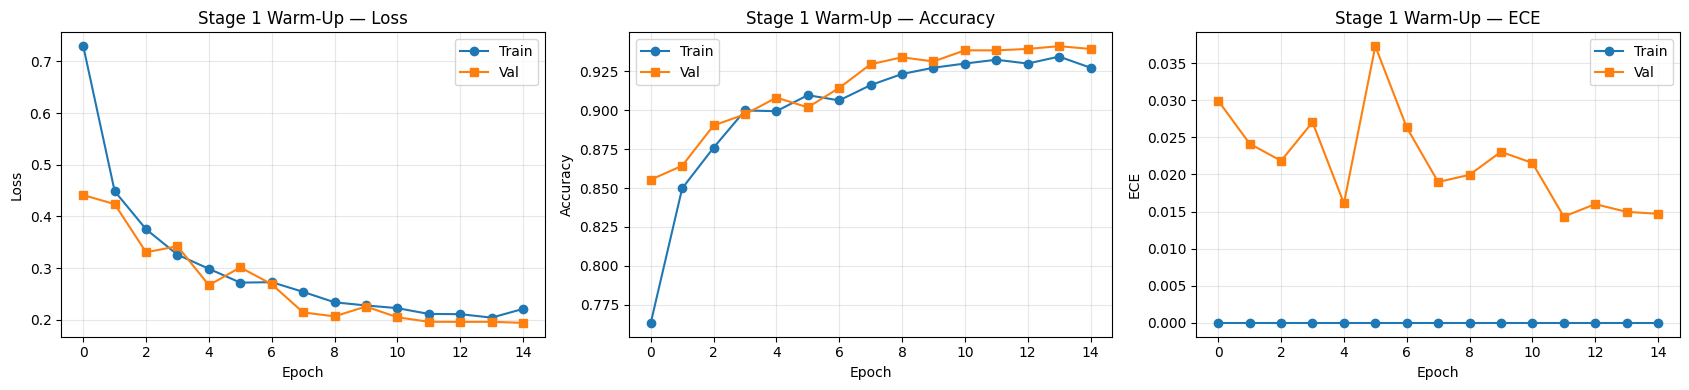

In [ ]:
#### CELL 11 RETRY — Stage 1 Warm-Up
os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)

for p in model.cnn.parameters():  p.requires_grad = False
for p in model.swin.parameters(): p.requires_grad = False

opt_w = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                   lr=CONFIG['lr_warmup'], weight_decay=CONFIG['weight_decay'])
sch_w = optim.lr_scheduler.CosineAnnealingLR(opt_w, T_max=CONFIG['epochs_warmup'])

hw = {'train_loss':[],'train_acc':[],'train_ece':[],
      'val_loss':  [],'val_acc':  [],'val_ece':  []}
best_acc = 0.0

print('='*65)
print('  Stage 1: Warm-Up  (CNN+Swin frozen)')
print('='*65)
print(f'{"Ep":>14} | {"TrLoss":>7} | {"TrAcc":>6} | {"VaLoss":>7} | {"VaAcc":>6} | {"VaECE":>6}')
print('-'*65)

for ep in range(1, CONFIG['epochs_warmup']+1):

    # ── Train ───────────────────────────────────────────────────────────
    model.train()
    tl, tp, tlab = 0.0, [], []
    n_batches = len(train_loader)

    for batch_idx, (imgs, labs) in enumerate(train_loader, 1):
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        opt_w.zero_grad()
        logits = model(imgs)
        loss, _, _ = criterion(logits, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt_w.step()
        tl += loss.item()
        tp.extend(logits.detach().argmax(1).cpu().numpy())
        tlab.extend(labs.cpu().numpy())
        print(f'\r  Ep {ep}/{CONFIG["epochs_warmup"]} '
              f'Train [{batch_idx}/{n_batches}] '
              f'AvgLoss: {tl/batch_idx:.4f}', end='', flush=True)

    tr_loss = tl / n_batches
    tr_acc  = accuracy_score(tlab, tp)

    # ── Validate ─────────────────────────────────────────────────────────
    model.eval()
    vl, vp, vlab, vlog = 0.0, [], [], []
    n_val = len(val_loader)

    with torch.no_grad():
        for batch_idx, (imgs, labs) in enumerate(val_loader, 1):
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            lg = model(imgs)
            loss, _, _ = criterion(lg, labs)
            vl += loss.item()
            vp.extend(lg.argmax(1).cpu().numpy())
            vlab.extend(labs.cpu().numpy())
            vlog.append(lg.cpu().numpy())
            print(f'\r  Ep {ep}/{CONFIG["epochs_warmup"]} '
                  f'Val   [{batch_idx}/{n_val}] '
                  f'AvgLoss: {vl/batch_idx:.4f}', end='', flush=True)

    print('\r', end='')

    va_loss = vl / n_val
    va_acc  = accuracy_score(vlab, vp)
    va_ece  = compute_ece(np.concatenate(vlog), np.array(vlab))

    hw['train_loss'].append(tr_loss); hw['train_acc'].append(tr_acc); hw['train_ece'].append(0)
    hw['val_loss'].append(va_loss);   hw['val_acc'].append(va_acc);   hw['val_ece'].append(va_ece)
    sch_w.step()

    # ── Always save every epoch, keep best ───────────────────────────────
    flag = ''
    if va_acc > best_acc:
        best_acc = va_acc
        torch.save(model.state_dict(), f'{CONFIG["checkpoint_dir"]}/best_warmup.pt')
        flag = '  ✔ SAVED'

    # Also save latest regardless
    torch.save(model.state_dict(), f'{CONFIG["checkpoint_dir"]}/latest_warmup.pt')

    print(f'{ep:>14} | {tr_loss:>7.4f} | {tr_acc:>6.4f} | '
          f'{va_loss:>7.4f} | {va_acc:>6.4f} | {va_ece:>6.4f}{flag}')

    # Verify file was saved
    if os.path.exists(f'{CONFIG["checkpoint_dir"]}/best_warmup.pt'):
        sz = os.path.getsize(f'{CONFIG["checkpoint_dir"]}/best_warmup.pt')/1e6
        print(f'       💾 Verified: best_warmup.pt ({sz:.1f} MB) exists on disk')

print('='*65)
print(f'Best Val Acc : {best_acc:.4f}')
print(f'Checkpoint   : {CONFIG["checkpoint_dir"]}/best_warmup.pt')
print('='*65)
plot_history(hw, 'Stage 1 Warm-Up')


  Stage 2: End-to-End Fine-Tuning
            Ep |               TrLoss |  TrAcc |  VaLoss |  VaAcc |  VaECE |       LR
------------------------------------------------------------------------


             1 |  0.3895 | 0.8810 |  0.2116 | 0.9402 | 0.0361 |  1.0e-04  ✔ SAVED


             2 |  0.2017 | 0.9496 |  0.1483 | 0.9598 | 0.0290 |  1.0e-04  ✔ SAVED


             3 |  0.1437 | 0.9658 |  0.1608 | 0.9580 | 0.0277 |  1.0e-04


             4 |  0.1325 | 0.9667 |  0.1081 | 0.9786 | 0.0171 |  1.0e-04  ✔ SAVED


...

            18 |  0.0065 | 0.9980 |  0.0574 | 0.9911 | 0.0089 |  1.3e-05


            19 |  0.0094 | 0.9971 |  0.0576 | 0.9920 | 0.0081 |  1.3e-05


            20 |  0.0130 | 0.9971 |  0.0550 | 0.9911 | 0.0082 |  1.3e-05


            21 |  0.0128 | 0.9967 |  0.0482 | 0.9929 | 0.0063 |  6.3e-06


            22 |  0.0052 | 0.9984 |  0.0385 | 0.9946 | 0.0055 |  6.3e-06
  ⚠ Early stopping at epoch 22
Best Val Acc: 0.9955


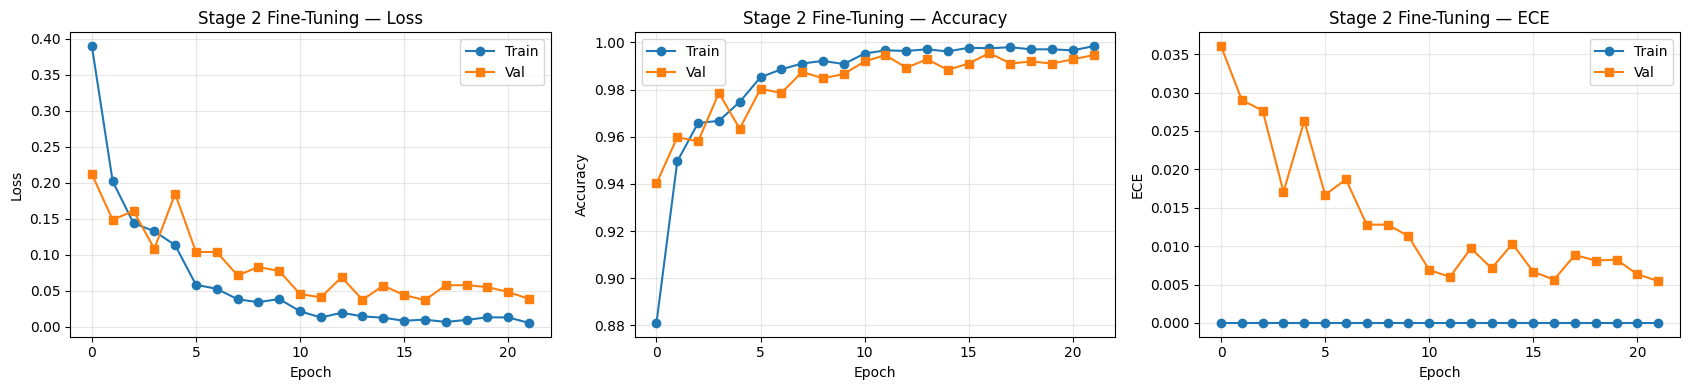

In [ ]:
# CELL 12 — Stage 2: End-to-End Fine-Tuning
model.load_state_dict(torch.load(f'{CONFIG["checkpoint_dir"]}/best_warmup.pt', map_location=DEVICE))
for p in model.parameters(): p.requires_grad=True

opt_f = optim.Adam(model.parameters(), lr=CONFIG['lr_full'], weight_decay=CONFIG['weight_decay'])
sch_f = optim.lr_scheduler.StepLR(opt_f, step_size=5, gamma=0.5)

hf = {'train_loss':[],'train_acc':[],'train_ece':[],'val_loss':[],'val_acc':[],'val_ece':[]}
best_acc, patience, no_imp = 0.0, 5, 0

print('='*72)
print('  Stage 2: End-to-End Fine-Tuning')
print('='*72)
print(f'{"Ep":>14} | {"TrLoss":>20} | {"TrAcc":>6} | {"VaLoss":>7} | {"VaAcc":>6} | {"VaECE":>6} | {"LR":>8}')
print('-'*72)

for ep in range(1, CONFIG['epochs_full']+1):
    model.train()
    tl,tp,tlab = 0,[],[]
    for imgs,labs in tqdm(train_loader,desc=f'Ep{ep:02d}Tr',leave=False,
                          bar_format='{l_bar}{bar:12}{r_bar}'):
        imgs,labs = imgs.to(DEVICE),labs.to(DEVICE)
        opt_f.zero_grad()
        lg = model(imgs)
        loss,_,_ = criterion(lg,labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        opt_f.step()
        tl+=loss.item(); tp.extend(lg.detach().argmax(1).cpu().numpy())
        tlab.extend(labs.cpu().numpy())
    tr_loss=tl/len(train_loader); tr_acc=accuracy_score(tlab,tp)

    model.eval()
    vl,vp,vlab,vlog = 0,[],[],[]
    with torch.no_grad():
        for imgs,labs in tqdm(val_loader,desc=f'Ep{ep:02d}Va',leave=False,
                              bar_format='{l_bar}{bar:12}{r_bar}'):
            imgs,labs = imgs.to(DEVICE),labs.to(DEVICE)
            lg = model(imgs)
            loss,_,_ = criterion(lg,labs)
            vl+=loss.item(); vp.extend(lg.argmax(1).cpu().numpy())
            vlab.extend(labs.cpu().numpy()); vlog.append(lg.cpu().numpy())
    va_loss=vl/len(val_loader); va_acc=accuracy_score(vlab,vp)
    va_ece=compute_ece(np.concatenate(vlog),np.array(vlab))
    lr_now=opt_f.param_groups[0]['lr']

    hf['train_loss'].append(tr_loss); hf['train_acc'].append(tr_acc); hf['train_ece'].append(0)
    hf['val_loss'].append(va_loss);   hf['val_acc'].append(va_acc);   hf['val_ece'].append(va_ece)
    sch_f.step()

    flag=''
    if va_acc>best_acc:
        best_acc=va_acc; no_imp=0
        torch.save(model.state_dict(), f'{CONFIG["checkpoint_dir"]}/best_full.pt')
        flag='  ✔ SAVED'
    else: no_imp+=1

    print(f'{ep:>14} | {tr_loss:>7.4f} | {tr_acc:>6.4f} | {va_loss:>7.4f} | {va_acc:>6.4f} | {va_ece:>6.4f} | {lr_now:>8.1e}{flag}')
    if no_imp>=patience:
        print(f'  ⚠ Early stopping at epoch {ep}'); break

print('='*72)
print(f'Best Val Acc: {best_acc:.4f}')
plot_history(hf,'Stage 2 Fine-Tuning')

In [ ]:
# CELL 13 — Stage 3: Calibration
model.load_state_dict(torch.load(f'{CONFIG["checkpoint_dir"]}/best_full.pt', map_location=DEVICE))
for nm,p in model.named_parameters():
    p.requires_grad = (nm=='head.temperature')

opt_c = optim.Adam([model.head.temperature], lr=CONFIG['lr_calib'])

print('='*50)
print('  Stage 3: Calibration')

print('='*50)
print(f'{"Ep":>14} | {"VaAcc":>6} | {"VaECE":>6} | {"T":>7}')
print('-'*50)

for ep in range(1, CONFIG['epochs_calib']+1):
    model.train()
    for imgs,labs in tqdm(train_loader,desc=f'Calib{ep}',leave=False,
                          bar_format='{l_bar}{bar:12}{r_bar}'):
        imgs,labs = imgs.to(DEVICE),labs.to(DEVICE)
        opt_c.zero_grad()
        loss,_,_ = criterion(model(imgs,calibrate=True),labs)
        loss.backward(); opt_c.step()

    model.eval()
    vp,vlab,vlog=[],[],[]
    with torch.no_grad():
        for imgs,labs in val_loader:
            lg=model(imgs.to(DEVICE),calibrate=True)
            vp.extend(lg.argmax(1).cpu().numpy())
            vlab.extend(labs.numpy()); vlog.append(lg.cpu().numpy())
    va_acc=accuracy_score(vlab,vp)
    va_ece=compute_ece(np.concatenate(vlog),np.array(vlab))
    T=model.head.temperature.item()
    print(f'{ep:>4} | {va_acc:>6.4f} | {va_ece:>6.4f} | {T:>7.4f}')

torch.save(model.state_dict(), f'{CONFIG["checkpoint_dir"]}/best_calibrated.pt')
print('Calibrated model saved ✓')

  Stage 3: Calibration
            Ep |  VaAcc |  VaECE |       T
--------------------------------------------------


   1 | 0.9946 | 0.0054 |  1.0264


   2 | 0.9946 | 0.0057 |  1.0608


   3 | 0.9946 | 0.0048 |  1.0907


   4 | 0.9946 | 0.0054 |  1.1179


...

  11 | 0.9946 | 0.0050 |  1.2144


  12 | 0.9955 | 0.0055 |  1.2222


  13 | 0.9946 | 0.0054 |  1.2530


  14 | 0.9946 | 0.0055 |  1.2544


  15 | 0.9946 | 0.0055 |  1.2565
Calibrated model saved ✓


In [ ]:
 # CELL 14 — Final Test Evaluation
model.load_state_dict(torch.load(f'{CONFIG["checkpoint_dir"]}/best_calibrated.pt', map_location=DEVICE))
model.eval()
for p in model.parameters(): p.requires_grad=False

test_preds_l,test_labs_l,test_logits_l=[],[],[]
with torch.no_grad():
    for imgs,labs in tqdm(test_loader,desc='Testing',bar_format='{l_bar}{bar:15}{r_bar}'):
        lg=model(imgs.to(DEVICE),calibrate=True)
        test_preds_l.extend(lg.argmax(1).cpu().numpy())
        test_labs_l.extend(labs.numpy())
        test_logits_l.append(lg.cpu().numpy())

test_logits = np.concatenate(test_logits_l)
test_labels = np.array(test_labs_l)
test_preds  = np.array(test_preds_l)
test_probs  = torch.softmax(torch.tensor(test_logits),1).numpy()

test_acc = accuracy_score(test_labels, test_preds)
test_ece = compute_ece(test_logits, test_labels)
prec     = precision_score(test_labels, test_preds, average='macro')
rec      = recall_score(test_labels, test_preds, average='macro')
f1       = f1_score(test_labels, test_preds, average='macro')
try:    auc = roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro')
except: auc = float('nan')

print('='*50)
print(f'  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print(f'  ECE       : {test_ece:.4f}')
print('='*50)
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

Testing: 100%|███████████████| 100/100 [08:11<00:00,  4.91s/it]

  Accuracy  : 0.9531  (95.31%)
  Precision : 0.9567
  Recall    : 0.9531
  F1-Score  : 0.9521
  ROC-AUC   : 0.9861
  ECE       : 0.0444
              precision    recall  f1-score   support

      Glioma       1.00      0.83      0.91       400
  Meningioma       0.90      0.99      0.94       400
   Pituitary       0.99      1.00      1.00       400
      Normal       0.93      1.00      0.97       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600



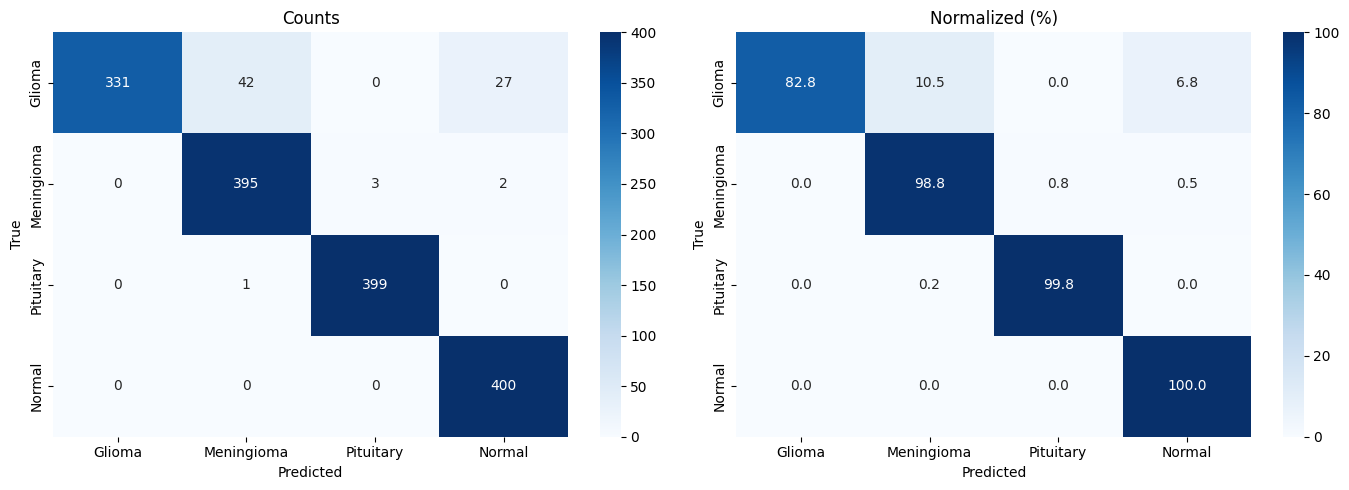

In [ ]:
# CELL 15 — Confusion Matrix
cm=confusion_matrix(test_labels,test_preds)
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,d,f,t in zip(axes,[cm,cm.astype(float)/cm.sum(1,keepdims=True)*100],
                    ['d','.1f'],['Counts','Normalized (%)']):
    sns.heatmap(d,annot=True,fmt=f,cmap='Blues',
                xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(t)
plt.tight_layout(); plt.show()

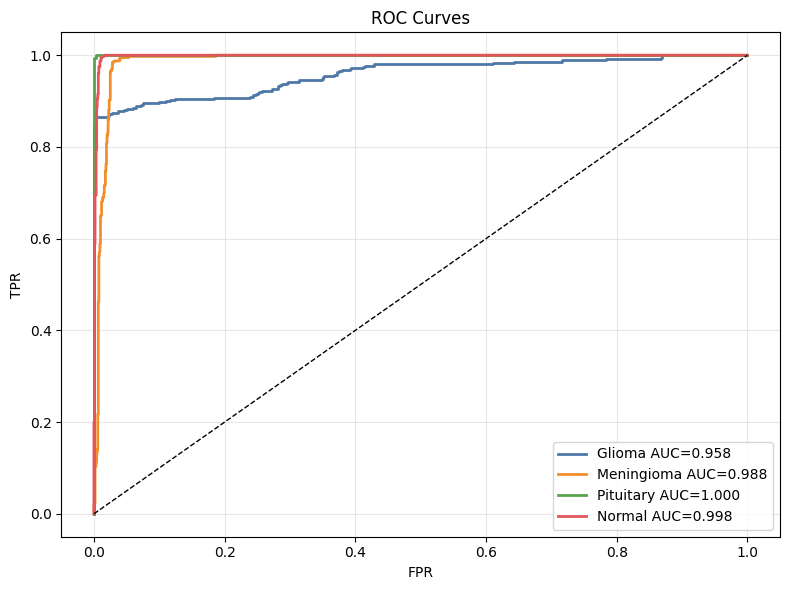

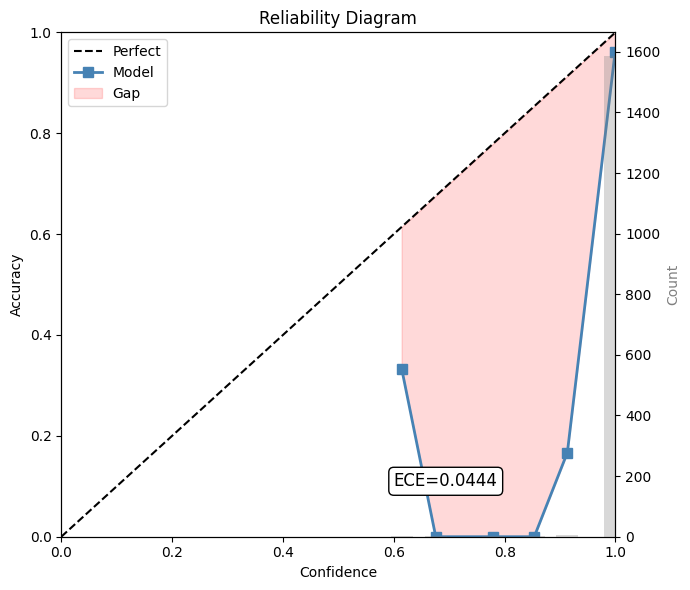

In [ ]:
# CELL 16 — ROC Curves + Reliability Diagram
# ROC
yb=label_binarize(test_labels,classes=list(range(4)))
fig,ax=plt.subplots(figsize=(8,6))
for i,(cls,col) in enumerate(zip(CLASS_NAMES,['#4e79a7','#f28e2b','#59a14f','#e15759'])):
    fpr,tpr,_=roc_curve(yb[:,i],test_probs[:,i])
    ax.plot(fpr,tpr,color=col,lw=2,label=f'{cls} AUC={sk_auc(fpr,tpr):.3f}')
ax.plot([0,1],[0,1],'k--',lw=1); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Reliability
conf_np=test_probs.max(1); corr_np=(test_probs.argmax(1)==test_labels).astype(float)
bins=np.linspace(0,1,16); bc,ba,bn=[],[],[]
for lo,hi in zip(bins[:-1],bins[1:]):
    m=(conf_np>=lo)&(conf_np<hi)
    if m.sum()>0: bc.append(conf_np[m].mean()); ba.append(corr_np[m].mean()); bn.append(m.sum())
fig,ax1=plt.subplots(figsize=(7,6)); ax2=ax1.twinx()
ax1.plot([0,1],[0,1],'k--',lw=1.5,label='Perfect')
ax1.plot(bc,ba,'s-',color='steelblue',lw=2,ms=7,label='Model')
ax1.fill_between(bc,bc,ba,alpha=0.15,color='red',label='Gap')
ax2.bar(bc,bn,width=0.04,alpha=0.3,color='gray'); ax2.set_ylabel('Count',color='gray')
ax1.set_xlabel('Confidence'); ax1.set_ylabel('Accuracy'); ax1.set_title('Reliability Diagram')
ax1.legend(loc='upper left'); ax1.set_xlim(0,1); ax1.set_ylim(0,1)
ax1.text(0.6,0.1,f'ECE={test_ece:.4f}',fontsize=12,
         bbox=dict(facecolor='white',edgecolor='black',boxstyle='round,pad=0.3'))
plt.tight_layout(); plt.show()

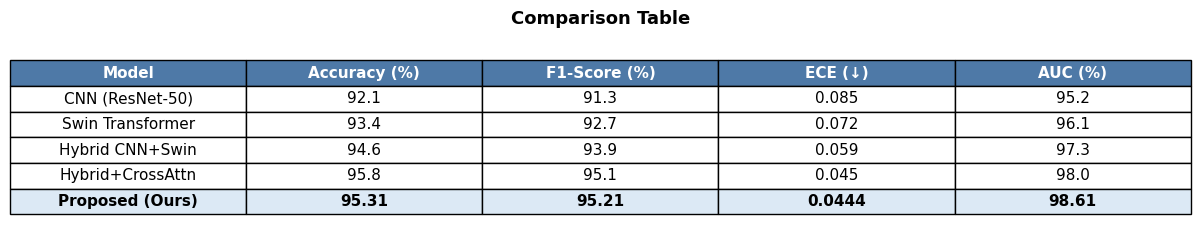

           Model  Accuracy (%)  F1-Score (%)  ECE (↓)  AUC (%)
 CNN (ResNet-50)         92.10         91.30   0.0850    95.20
Swin Transformer         93.40         92.70   0.0720    96.10
 Hybrid CNN+Swin         94.60         93.90   0.0590    97.30
Hybrid+CrossAttn         95.80         95.10   0.0450    98.00
 Proposed (Ours)         95.31         95.21   0.0444    98.61


In [ ]:
# CELL 17 — Comparison Table
df=pd.DataFrame({
    'Model'       :['CNN (ResNet-50)','Swin Transformer','Hybrid CNN+Swin',
                    'Hybrid+CrossAttn','Proposed (Ours)'],
    'Accuracy (%)':[92.1,93.4,94.6,95.8,round(test_acc*100,2)],
    'F1-Score (%)':[91.3,92.7,93.9,95.1,round(f1*100,2)],
    'ECE (↓)'     :[0.085,0.072,0.059,0.045,round(test_ece,4)],
    'AUC (%)'     :[95.2,96.1,97.3,98.0,round(auc*100,2) if not np.isnan(auc) else '-'],
})
fig,ax=plt.subplots(figsize=(12,2.5)); ax.axis('off')
tbl=ax.table(cellText=df.values,colLabels=df.columns,cellLoc='center',loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2,1.6)
for j in range(len(df.columns)):
    tbl[0,j].set_facecolor('#4e79a7'); tbl[0,j].set_text_props(color='white',fontweight='bold')
    tbl[len(df),j].set_facecolor('#dce9f5'); tbl[len(df),j].set_text_props(fontweight='bold')
plt.title('Comparison Table',fontsize=13,fontweight='bold',pad=15)
plt.tight_layout(); plt.show()
print(df.to_string(index=False))

In [ ]:
# CELL 18 — Save Metrics
res={'accuracy':round(test_acc,4),'precision':round(prec,4),
     'recall':round(rec,4),'f1_score':round(f1,4),
     'roc_auc':round(float(auc),4) if not np.isnan(auc) else None,
     'ece':round(test_ece,4),
     'temperature':round(model.head.temperature.item(),4)}
pd.DataFrame([res]).to_csv(f'{CONFIG["checkpoint_dir"]}/final_metrics.csv',index=False)
print('Final Results:')
print('-'*32)
for k,v in res.items(): print(f'  {k:<15}: {v}')
print('-'*32)
print(f'\n✅ Saved to {CONFIG["checkpoint_dir"]}/')

Final Results:
--------------------------------
  accuracy       : 0.9531
  precision      : 0.9567
  recall         : 0.9531
  f1_score       : 0.9521
  roc_auc        : 0.9861
  ece            : 0.0444
  temperature    : 1.2565
--------------------------------

✅ Saved to ./checkpoints/
